# KNN - Exercícios de Revisão e Fixação
Implementação do K-Nearest Neighbors usando apenas NumPy e Matplotlib, seguindo o mesmo padrão do notebook `analise_knn_tumores.ipynb` (Aula 7).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
def calcular_distancia_euclidiana(ponto1, ponto2):
    """Calcula a distância euclidiana entre dois pontos."""
    return np.sqrt(np.sum((ponto1 - ponto2)**2))

def encontrar_vizinhos(X_train, y_train, ponto_teste, k):
    """Encontra os k vizinhos mais próximos de um ponto de teste."""
    distancias = []
    for i, ponto_treino in enumerate(X_train):
        dist = calcular_distancia_euclidiana(ponto_treino, ponto_teste)
        distancias.append((dist, y_train[i]))
    
    # Ordena a lista de distâncias em ordem crescente
    distancias.sort(key=lambda x: x[0])
    
    # Retorna os k vizinhos mais próximos (seus rótulos)
    vizinhos = [distancia[1] for distancia in distancias[:k]]
    return vizinhos

def prever_classificacao(vizinhos):
    """Faz a previsão com base no voto majoritário dos vizinhos."""
    # Conta a ocorrência de cada classe nos vizinhos
    contagem_votos = Counter(vizinhos)
    # Retorna a classe mais comum
    previsao = contagem_votos.most_common(1)[0][0]
    return previsao

# Exercício 1
Clientes de supermercado classificados em grupos de consumo (1 = baixo, 2 = médio, 3 = alto) com base em `Renda_Mensal` e `Gasto_Mensal`.

In [3]:
# Carrega os dados do txt. Delimiter='|' indica que as colunas são separadas por barra vertical.
# skiprows=2 para pular as duas linhas de cabeçalho (nomes das colunas e linha de traços)
# usecols=(1, 2, 3) ignora as colunas vazias antes do primeiro e depois do último '|'
dataset = np.loadtxt("knn_dataset_exercicio_1.txt", delimiter='|', skiprows=2, usecols=(1, 2, 3))

# Separa as colunas de caracteristicas (features) e a coluna de rótulos (labels)
X_train = dataset[:, :2]
y_train = dataset[:, 2].astype(int)

print("Amostra das caracteristicas (X_train):")
print(X_train[:5])
print("\nAmostra dos rotulos (y_train):")
print(y_train[:5])

Amostra das caracteristicas (X_train):
[[2000.  500.]
 [2500.  700.]
 [3000.  800.]
 [3200. 1000.]
 [3500. 1200.]]

Amostra dos rotulos (y_train):
[1 1 1 2 2]


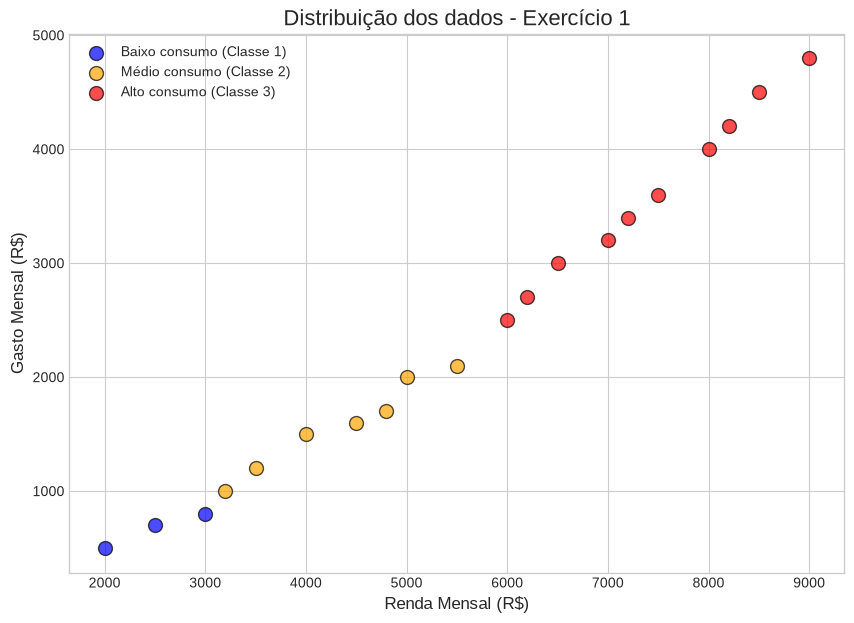

In [4]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 7))

# Plota os pontos de cada classe
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           c='blue', s=100, edgecolor='k', alpha=0.7, label='Baixo consumo (Classe 1)')
ax.scatter(X_train[y_train == 2, 0], X_train[y_train == 2, 1],
           c='orange', s=100, edgecolor='k', alpha=0.7, label='Médio consumo (Classe 2)')
ax.scatter(X_train[y_train == 3, 0], X_train[y_train == 3, 1],
           c='red', s=100, edgecolor='k', alpha=0.7, label='Alto consumo (Classe 3)')

ax.set_title('Distribuição dos dados - Exercício 1', fontsize=16)
ax.set_xlabel('Renda Mensal (R$)', fontsize=12)
ax.set_ylabel('Gasto Mensal (R$)', fontsize=12)
ax.legend()
plt.show()

In [5]:
# Ponto que queremos classificar
novo_ponto = np.array([9000, 1000])   # renda alta, gasto baixo
k = 1

# Encontra os vizinhos e faz a previsão
vizinhos_proximos = encontrar_vizinhos(X_train, y_train, novo_ponto, k)
previsao_final = prever_classificacao(vizinhos_proximos)

print(f"O novo ponto tem as características: {novo_ponto}")
print(f"O valor de 'k' escolhido foi: {k}")
print(f"As classes dos vizinhos mais próximos são: {vizinhos_proximos}")
print("-" * 50)
print(f"--> Previsão Final: classe {previsao_final}")

O novo ponto tem as características: [9000 1000]
O valor de 'k' escolhido foi: 1
As classes dos vizinhos mais próximos são: [np.int64(3)]
--------------------------------------------------
--> Previsão Final: classe 3


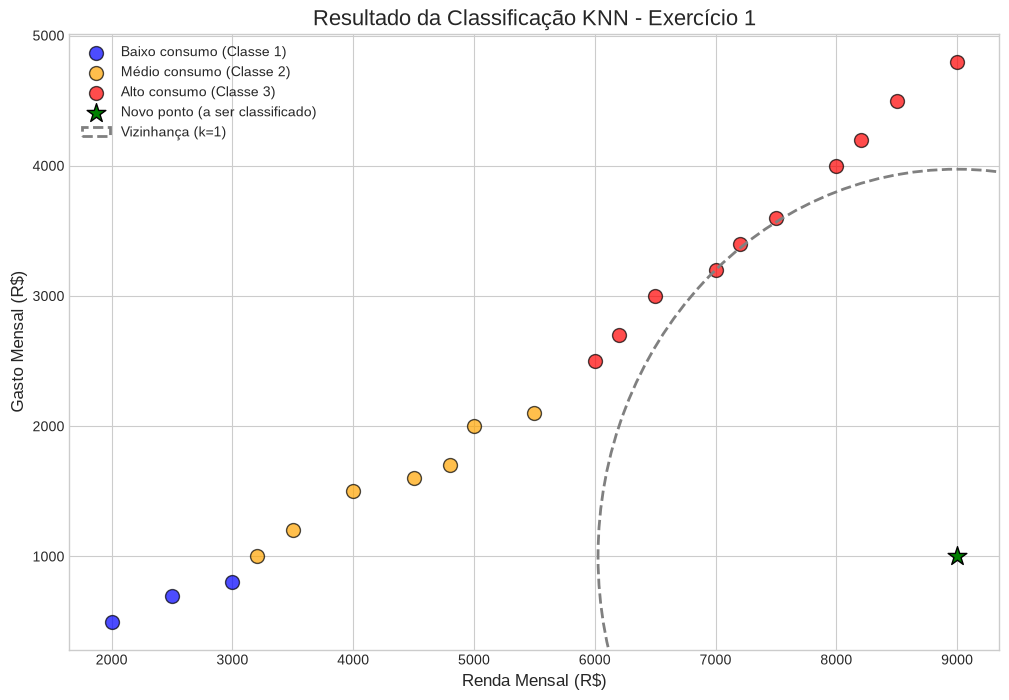

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plotando os pontos de dados de treinamento
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           c='blue', s=100, edgecolor='k', alpha=0.7, label='Baixo consumo (Classe 1)')
ax.scatter(X_train[y_train == 2, 0], X_train[y_train == 2, 1],
           c='orange', s=100, edgecolor='k', alpha=0.7, label='Médio consumo (Classe 2)')
ax.scatter(X_train[y_train == 3, 0], X_train[y_train == 3, 1],
           c='red', s=100, edgecolor='k', alpha=0.7, label='Alto consumo (Classe 3)')

# Plotando o novo ponto de dados a ser classificado
ax.scatter(novo_ponto[0], novo_ponto[1], c='green', s=200,
           edgecolor='k', marker='*', label='Novo ponto (a ser classificado)')

# Destaque para os vizinhos mais próximos
indices_vizinhos = np.argsort([calcular_distancia_euclidiana(p, novo_ponto) for p in X_train])[:k]
pontos_vizinhos = X_train[indices_vizinhos]

# Desenhando um círculo que engloba os vizinhos
distancia_maxima = calcular_distancia_euclidiana(novo_ponto, pontos_vizinhos[-1])
circulo = plt.Circle(novo_ponto, distancia_maxima, color='gray', fill=False,
                     linestyle='--', linewidth=2, label=f'Vizinhança (k={k})')
ax.add_artist(circulo)

# Configurações do gráfico
ax.set_title('Resultado da Classificação KNN - Exercício 1', fontsize=16)
ax.set_xlabel('Renda Mensal (R$)', fontsize=12)
ax.set_ylabel('Gasto Mensal (R$)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True)
ax.set_aspect('auto')
plt.show()

In [7]:
# Testando diferentes valores de k para o mesmo ponto
for k in [1, 3, 5, 9, 15]:
    vizinhos = encontrar_vizinhos(X_train, y_train, novo_ponto, k)
    print(f"k = {k:2d} -> vizinhos: {vizinhos} -> classe {prever_classificacao(vizinhos)}")

k =  1 -> vizinhos: [np.int64(3)] -> classe 3
k =  3 -> vizinhos: [np.int64(3), np.int64(3), np.int64(3)] -> classe 3
k =  5 -> vizinhos: [np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3)] -> classe 3
k =  9 -> vizinhos: [np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3)] -> classe 3
k = 15 -> vizinhos: [np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(2)] -> classe 3


In [8]:
# Clientes na região de fronteira entre os grupos e cliente típico de cada grupo
for ponto in [np.array([3100, 900]), np.array([5800, 2300]), np.array([2200, 600]), np.array([8800, 4600])]:
    for k in [1, 5, 15]:
        v = encontrar_vizinhos(X_train, y_train, ponto, k)
        print(f"{ponto}  k={k:2d} -> classe {prever_classificacao(v)}  {v}")
    print()

[3100  900]  k= 1 -> classe 1  [np.int64(1)]
[3100  900]  k= 5 -> classe 2  [np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2)]
[3100  900]  k=15 -> classe 2  [np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3)]

[5800 2300]  k= 1 -> classe 3  [np.int64(3)]
[5800 2300]  k= 5 -> classe 3  [np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3)]
[5800 2300]  k=15 -> classe 3  [np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3), np.int64(2), np.int64(3)]

[2200  600]  k= 1 -> classe 1  [np.int64(1)]
[2200  600]  k= 5 -> classe 1  [np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2)]
[2200  600]  k=15 -> classe 2  [np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(2), np.int64

## Respostas - Exercício 1
**a) O KNN separou bem os grupos?** Sim. Os três grupos formam faixas bem definidas no gráfico (quanto maior a renda, maior o gasto) e os clientes típicos de cada grupo (ex.: `[2200, 600]`, `[8800, 4600]`) são classificados corretamente para qualquer k. A confusão só aparece na **fronteira entre baixo e médio consumo**: o cliente `[3100, 900]` é classificado como baixo consumo com k=1 e como médio com k=5, porque há pontos das duas classes a poucas centenas de reais um do outro.

**b) Renda alta e gasto baixo pode ser classificado errado?** Sim. O cliente `[9000, 1000]` foi classificado como **alto consumo (classe 3)** para todos os valores de k (1, 3, 5, 9 e 15), embora gaste pouco. Como o KNN só olha para o vizinho mais próximo e nos dados renda e gasto crescem juntos, esse cliente não tem nenhum semelhante no conjunto de treino; ele é classificado pela renda, que domina a distância. Isso indica que a segmentação com só duas variáveis fortemente correlacionadas assume que "quem ganha mais gasta mais" e não trata bem clientes que fogem desse padrão; seriam necessários mais atributos e mais exemplos desse perfil.

**c) Influência de k na fronteira.** Com k pequeno a fronteira segue cada ponto individual (mais sensível a ruído); com k grande ela fica mais suave, mas os grupos pequenos ou estreitos passam a ser dominados pelos vizinhos das outras classes. Isso aparece no cliente `[2200, 600]`, que é de baixo consumo com k=1 e k=5, mas passa a médio consumo com k=15, porque o voto inclui pontos de outras classes. Um k intermediário (3 a 5, sempre ímpar para evitar empate) equilibra melhor.

# Exercício 2
Previsão do nível de risco de crédito (1 = baixo, 2 = médio, 3 = alto) com base em `Idade` e `Divida`.

In [9]:
# Carrega os dados do txt. Delimiter='|' indica que as colunas são separadas por barra vertical.
# skiprows=2 para pular as duas linhas de cabeçalho (nomes das colunas e linha de traços)
# usecols=(1, 2, 3) ignora as colunas vazias antes do primeiro e depois do último '|'
dataset = np.loadtxt("knn_dataset_exercicio_2.txt", delimiter='|', skiprows=2, usecols=(1, 2, 3))

# Separa as colunas de caracteristicas (features) e a coluna de rótulos (labels)
X_train = dataset[:, :2]
y_train = dataset[:, 2].astype(int)

print("Amostra das caracteristicas (X_train):")
print(X_train[:5])
print("\nAmostra dos rotulos (y_train):")
print(y_train[:5])

Amostra das caracteristicas (X_train):
[[  22. 1500.]
 [  25. 2000.]
 [  28. 2500.]
 [  30. 1000.]
 [  32. 1200.]]

Amostra dos rotulos (y_train):
[3 3 3 2 2]


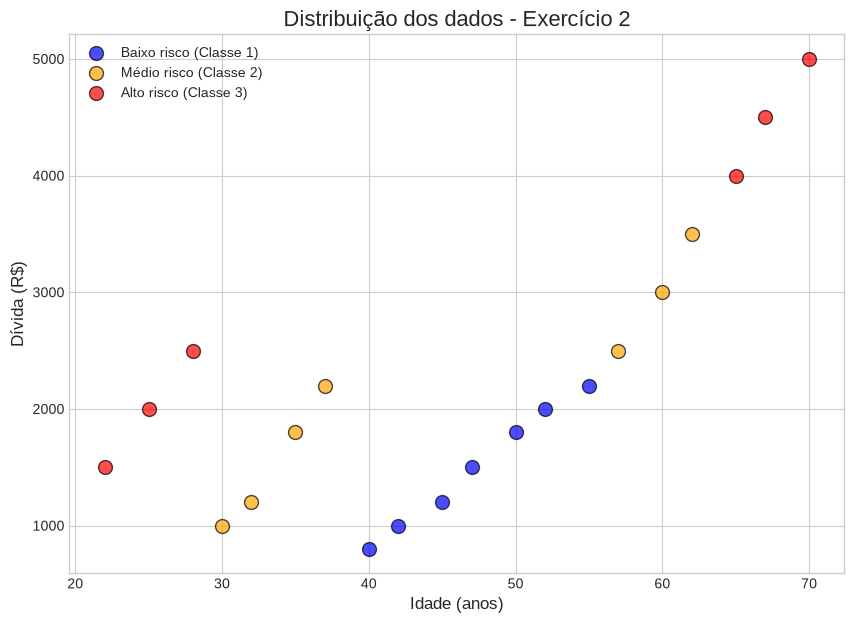

In [10]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 7))

# Plota os pontos de cada classe
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           c='blue', s=100, edgecolor='k', alpha=0.7, label='Baixo risco (Classe 1)')
ax.scatter(X_train[y_train == 2, 0], X_train[y_train == 2, 1],
           c='orange', s=100, edgecolor='k', alpha=0.7, label='Médio risco (Classe 2)')
ax.scatter(X_train[y_train == 3, 0], X_train[y_train == 3, 1],
           c='red', s=100, edgecolor='k', alpha=0.7, label='Alto risco (Classe 3)')

ax.set_title('Distribuição dos dados - Exercício 2', fontsize=16)
ax.set_xlabel('Idade (anos)', fontsize=12)
ax.set_ylabel('Dívida (R$)', fontsize=12)
ax.legend()
plt.show()

In [11]:
# Ponto que queremos classificar
novo_ponto = np.array([58, 2800])   # cliente de 58 anos com dívida de R$ 2800
k = 1

# Encontra os vizinhos e faz a previsão
vizinhos_proximos = encontrar_vizinhos(X_train, y_train, novo_ponto, k)
previsao_final = prever_classificacao(vizinhos_proximos)

print(f"O novo ponto tem as características: {novo_ponto}")
print(f"O valor de 'k' escolhido foi: {k}")
print(f"As classes dos vizinhos mais próximos são: {vizinhos_proximos}")
print("-" * 50)
print(f"--> Previsão Final: classe {previsao_final}")

O novo ponto tem as características: [  58 2800]
O valor de 'k' escolhido foi: 1
As classes dos vizinhos mais próximos são: [np.int64(2)]
--------------------------------------------------
--> Previsão Final: classe 2


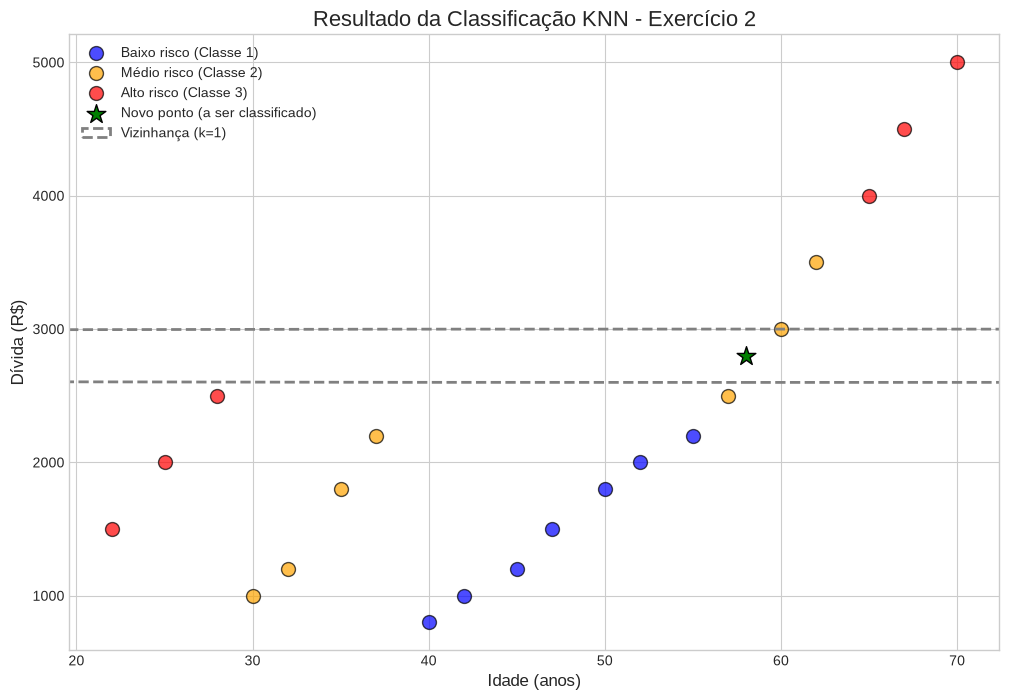

In [12]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plotando os pontos de dados de treinamento
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           c='blue', s=100, edgecolor='k', alpha=0.7, label='Baixo risco (Classe 1)')
ax.scatter(X_train[y_train == 2, 0], X_train[y_train == 2, 1],
           c='orange', s=100, edgecolor='k', alpha=0.7, label='Médio risco (Classe 2)')
ax.scatter(X_train[y_train == 3, 0], X_train[y_train == 3, 1],
           c='red', s=100, edgecolor='k', alpha=0.7, label='Alto risco (Classe 3)')

# Plotando o novo ponto de dados a ser classificado
ax.scatter(novo_ponto[0], novo_ponto[1], c='green', s=200,
           edgecolor='k', marker='*', label='Novo ponto (a ser classificado)')

# Destaque para os vizinhos mais próximos
indices_vizinhos = np.argsort([calcular_distancia_euclidiana(p, novo_ponto) for p in X_train])[:k]
pontos_vizinhos = X_train[indices_vizinhos]

# Desenhando um círculo que engloba os vizinhos
distancia_maxima = calcular_distancia_euclidiana(novo_ponto, pontos_vizinhos[-1])
circulo = plt.Circle(novo_ponto, distancia_maxima, color='gray', fill=False,
                     linestyle='--', linewidth=2, label=f'Vizinhança (k={k})')
ax.add_artist(circulo)

# Configurações do gráfico
ax.set_title('Resultado da Classificação KNN - Exercício 2', fontsize=16)
ax.set_xlabel('Idade (anos)', fontsize=12)
ax.set_ylabel('Dívida (R$)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True)
ax.set_aspect('auto')
plt.show()

In [13]:
# Testando diferentes valores de k para o mesmo ponto
for k in [1, 3, 5, 9, 15]:
    vizinhos = encontrar_vizinhos(X_train, y_train, novo_ponto, k)
    print(f"k = {k:2d} -> vizinhos: {vizinhos} -> classe {prever_classificacao(vizinhos)}")

k =  1 -> vizinhos: [np.int64(2)] -> classe 2
k =  3 -> vizinhos: [np.int64(2), np.int64(2), np.int64(3)] -> classe 2
k =  5 -> vizinhos: [np.int64(2), np.int64(2), np.int64(3), np.int64(1), np.int64(2)] -> classe 2
k =  9 -> vizinhos: [np.int64(2), np.int64(2), np.int64(3), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(3), np.int64(1)] -> classe 2
k = 15 -> vizinhos: [np.int64(2), np.int64(2), np.int64(3), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(3), np.int64(1), np.int64(2), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(2)] -> classe 2


In [14]:
# Outros clientes: um de cada perfil, para comparar os valores de k
for ponto in [np.array([26, 2200]), np.array([48, 1500]), np.array([33, 1500]), np.array([68, 4800]), np.array([45, 3000])]:
    for k in [1, 5, 9]:
        v = encontrar_vizinhos(X_train, y_train, ponto, k)
        print(f"{ponto}  k={k:2d} -> classe {prever_classificacao(v)}  {v}")
    print()

[  26 2200]  k= 1 -> classe 2  [np.int64(2)]
[  26 2200]  k= 5 -> classe 1  [np.int64(2), np.int64(1), np.int64(3), np.int64(1), np.int64(3)]
[  26 2200]  k= 9 -> classe 2  [np.int64(2), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(2), np.int64(2), np.int64(1), np.int64(3)]

[  48 1500]  k= 1 -> classe 1  [np.int64(1)]
[  48 1500]  k= 5 -> classe 1  [np.int64(1), np.int64(3), np.int64(1), np.int64(1), np.int64(2)]
[  48 1500]  k= 9 -> classe 1  [np.int64(1), np.int64(3), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2)]

[  33 1500]  k= 1 -> classe 3  [np.int64(3)]
[  33 1500]  k= 5 -> classe 1  [np.int64(3), np.int64(1), np.int64(2), np.int64(2), np.int64(1)]
[  33 1500]  k= 9 -> classe 1  [np.int64(3), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(3), np.int64(1)]

[  68 4800]  k= 1 -> classe 3  [np.int64(3)]
[  68 4800]  k= 5 -> classe 3  [np.int64(3), np.int64(3), np.int64(3), np.int64

## Respostas - Exercício 2
**a) O modelo diferenciou bem alto de baixo risco?** Parcialmente. Alto risco (clientes muito jovens ou idosos com dívida alta) e baixo risco (40 a 55 anos, dívida moderada) ficam em regiões distintas do gráfico, e clientes típicos como `[68, 4800]` (alto) e `[48, 1500]` (baixo) foram classificados corretamente para todos os k testados. O problema é que o risco tem formato de "U" em relação à idade (alto para jovens, baixo no meio, alto para idosos), e como a distância euclidiana está sendo calculada sem padronizar as variáveis, `Divida` (milhares) domina totalmente `Idade` (dezenas), o que piora a separação. Padronizar as variáveis seria o próximo passo.

**b) Há sobreposição do risco médio?** Sim. O grupo 2 aparece em duas regiões separadas (30 a 37 anos com dívida 1000 a 2200 e 57 a 62 anos com dívida 2500 a 3500), encostadas em clientes de baixo e alto risco. Por isso o cliente `[33, 1500]` é classificado como alto risco com k=1 e como baixo risco com k=5 e 9, mas nunca como médio (que é seu grupo natural), e o cliente `[26, 2200]` muda de classe (2 para 1 e depois 2) conforme k. O cliente `[58, 2800]`, que tem idade e dívida de médio risco, é classificado como médio em todos os k.

**c) Impacto de aumentar ou reduzir k.** Como há poucos clientes por grupo (6 ou 7) e os grupos são espalhados, o resultado é instável: k=1 depende de um único vizinho (pode ser ruído, como no cliente `[33, 1500]`), e k grande passa a misturar vizinhos de outras classes (com k=9 os vizinhos de `[58, 2800]` já incluem 3 de baixo e 2 de alto risco). Um k pequeno a médio (3 a 5) é o mais indicado, e o ideal seria escolhê-lo por validação com mais dados.

# Exercício 3
Classificação de funcionários em níveis de desempenho (1 = baixo, 2 = médio, 3 = alto) com base em `Horas_Treinamento` e `Projetos_Entregues`.

In [15]:
# Carrega os dados do txt. Delimiter='|' indica que as colunas são separadas por barra vertical.
# skiprows=2 para pular as duas linhas de cabeçalho (nomes das colunas e linha de traços)
# usecols=(1, 2, 3) ignora as colunas vazias antes do primeiro e depois do último '|'
dataset = np.loadtxt("knn_dataset_exercicio_3.txt", delimiter='|', skiprows=2, usecols=(1, 2, 3))

# Separa as colunas de caracteristicas (features) e a coluna de rótulos (labels)
X_train = dataset[:, :2]
y_train = dataset[:, 2].astype(int)

print("Amostra das caracteristicas (X_train):")
print(X_train[:5])
print("\nAmostra dos rotulos (y_train):")
print(y_train[:5])

Amostra das caracteristicas (X_train):
[[ 5.  1.]
 [ 6.  2.]
 [ 8.  2.]
 [10.  3.]
 [12.  4.]]

Amostra dos rotulos (y_train):
[1 1 1 1 2]


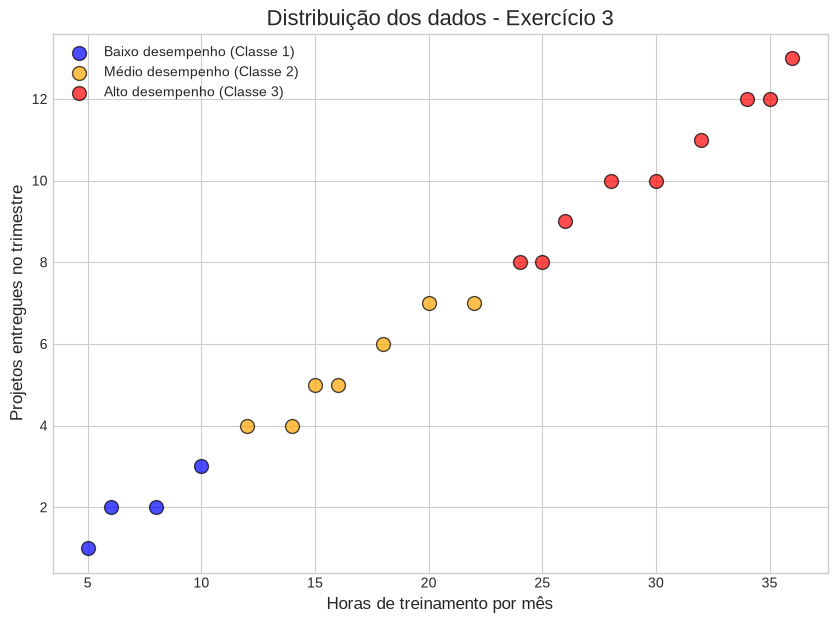

In [16]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 7))

# Plota os pontos de cada classe
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           c='blue', s=100, edgecolor='k', alpha=0.7, label='Baixo desempenho (Classe 1)')
ax.scatter(X_train[y_train == 2, 0], X_train[y_train == 2, 1],
           c='orange', s=100, edgecolor='k', alpha=0.7, label='Médio desempenho (Classe 2)')
ax.scatter(X_train[y_train == 3, 0], X_train[y_train == 3, 1],
           c='red', s=100, edgecolor='k', alpha=0.7, label='Alto desempenho (Classe 3)')

ax.set_title('Distribuição dos dados - Exercício 3', fontsize=16)
ax.set_xlabel('Horas de treinamento por mês', fontsize=12)
ax.set_ylabel('Projetos entregues no trimestre', fontsize=12)
ax.legend()
plt.show()

In [17]:
# Ponto que queremos classificar
novo_ponto = np.array([20, 3])   # 20 horas de treinamento e 3 projetos entregues
k = 1

# Encontra os vizinhos e faz a previsão
vizinhos_proximos = encontrar_vizinhos(X_train, y_train, novo_ponto, k)
previsao_final = prever_classificacao(vizinhos_proximos)

print(f"O novo ponto tem as características: {novo_ponto}")
print(f"O valor de 'k' escolhido foi: {k}")
print(f"As classes dos vizinhos mais próximos são: {vizinhos_proximos}")
print("-" * 50)
print(f"--> Previsão Final: classe {previsao_final}")

O novo ponto tem as características: [20  3]
O valor de 'k' escolhido foi: 1
As classes dos vizinhos mais próximos são: [np.int64(2)]
--------------------------------------------------
--> Previsão Final: classe 2


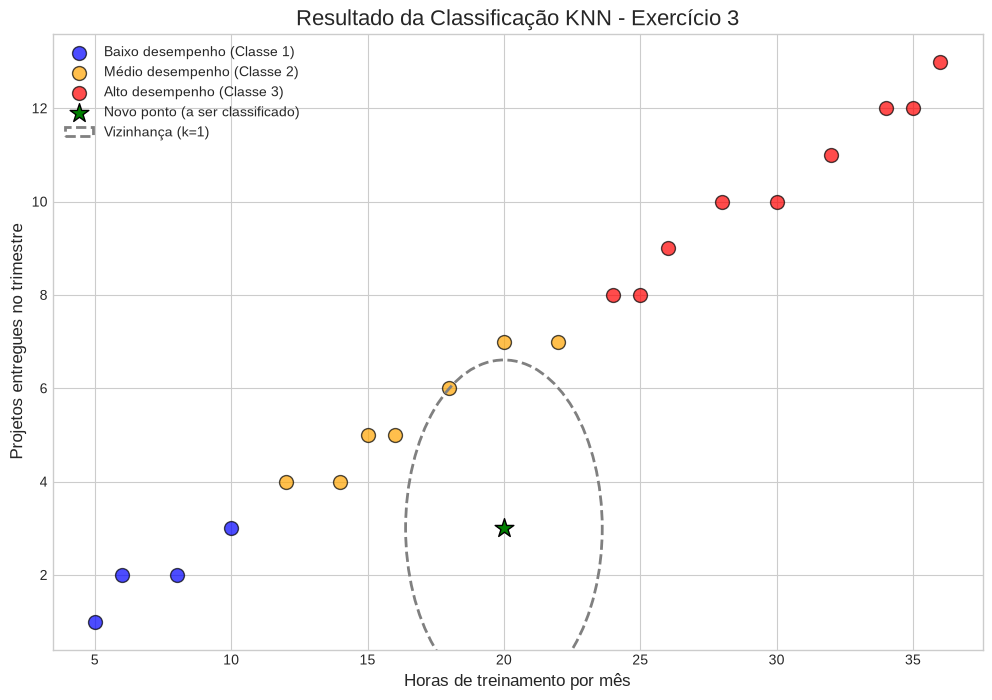

In [18]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plotando os pontos de dados de treinamento
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           c='blue', s=100, edgecolor='k', alpha=0.7, label='Baixo desempenho (Classe 1)')
ax.scatter(X_train[y_train == 2, 0], X_train[y_train == 2, 1],
           c='orange', s=100, edgecolor='k', alpha=0.7, label='Médio desempenho (Classe 2)')
ax.scatter(X_train[y_train == 3, 0], X_train[y_train == 3, 1],
           c='red', s=100, edgecolor='k', alpha=0.7, label='Alto desempenho (Classe 3)')

# Plotando o novo ponto de dados a ser classificado
ax.scatter(novo_ponto[0], novo_ponto[1], c='green', s=200,
           edgecolor='k', marker='*', label='Novo ponto (a ser classificado)')

# Destaque para os vizinhos mais próximos
indices_vizinhos = np.argsort([calcular_distancia_euclidiana(p, novo_ponto) for p in X_train])[:k]
pontos_vizinhos = X_train[indices_vizinhos]

# Desenhando um círculo que engloba os vizinhos
distancia_maxima = calcular_distancia_euclidiana(novo_ponto, pontos_vizinhos[-1])
circulo = plt.Circle(novo_ponto, distancia_maxima, color='gray', fill=False,
                     linestyle='--', linewidth=2, label=f'Vizinhança (k={k})')
ax.add_artist(circulo)

# Configurações do gráfico
ax.set_title('Resultado da Classificação KNN - Exercício 3', fontsize=16)
ax.set_xlabel('Horas de treinamento por mês', fontsize=12)
ax.set_ylabel('Projetos entregues no trimestre', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True)
ax.set_aspect('auto')
plt.show()

In [19]:
# Testando diferentes valores de k para o mesmo ponto
for k in [1, 3, 5, 9, 15]:
    vizinhos = encontrar_vizinhos(X_train, y_train, novo_ponto, k)
    print(f"k = {k:2d} -> vizinhos: {vizinhos} -> classe {prever_classificacao(vizinhos)}")

k =  1 -> vizinhos: [np.int64(2)] -> classe 2
k =  3 -> vizinhos: [np.int64(2), np.int64(2), np.int64(2)] -> classe 2
k =  5 -> vizinhos: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2)] -> classe 2
k =  9 -> vizinhos: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(3), np.int64(3), np.int64(2)] -> classe 2
k = 15 -> vizinhos: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(3), np.int64(3), np.int64(2), np.int64(3), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(1)] -> classe 2


In [20]:
# Muitas horas de treinamento e poucos projetos, e outros casos
for ponto in [np.array([35, 3]), np.array([30, 5]), np.array([10, 8]), np.array([23, 7.5])]:
    for k in [1, 5, 9]:
        v = encontrar_vizinhos(X_train, y_train, ponto, k)
        print(f"{ponto}  k={k:2d} -> classe {prever_classificacao(v)}  {v}")
    print()

[35  3]  k= 1 -> classe 3  [np.int64(3)]
[35  3]  k= 5 -> classe 3  [np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3)]
[35  3]  k= 9 -> classe 3  [np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3)]

[30  5]  k= 1 -> classe 3  [np.int64(3)]
[30  5]  k= 5 -> classe 3  [np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3)]
[30  5]  k= 9 -> classe 3  [np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(2), np.int64(3)]

[10  8]  k= 1 -> classe 2  [np.int64(2)]
[10  8]  k= 5 -> classe 2  [np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(1)]
[10  8]  k= 9 -> classe 2  [np.int64(2), np.int64(1), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1)]

[23.   7.5]  k= 1 -> classe 2  [np.int64(2)]
[23.   7.5]  k= 5 -> classe 3  [np.int64(2), np.int64(3), np.int64(3), np.int64(2), np.int64(3)]
[23.   7.5]  k= 9 

## Respostas - Exercício 3
**a) O KNN separou corretamente os funcionários?** Sim, em geral. As variáveis crescem juntas e os três níveis formam faixas quase lineares e bem separadas. Os pontos de cada nível recebem a classe certa (ex.: `[30, 5]` é alto desempenho para todos os k e `[35, 3]` também). Só há dúvida na fronteira entre médio e alto: o ponto `[23, 7.5]` é médio com k=1 e alto com k=5 e 9.

**b) Muitas horas e poucos projetos podem ser classificados errado?** Sim. O funcionário `[35, 3]` (35 horas de treinamento, só 3 projetos) foi classificado como **alto desempenho** para k=1, 5 e 9, pois `Horas_Treinamento` tem escala maior e domina a distância; porém, com 3 projetos ele entregou muito pouco. Isso sugere que os atributos são redundantes (horas e projetos crescem juntos nos dados de treino) e que horas de treinamento é um insumo, não uma medida de desempenho. Seria melhor usar atributos que diferenciem esses perfis (ex.: projetos por hora de treinamento, complexidade dos projetos) ou padronizar as variáveis.

**c) Novo funcionário com 20 horas e 3 projetos.** O KNN o classifica como **nível 2 (médio desempenho)**, para k = 1, 3, 5, 9 e 15 (todos os vizinhos mais próximos até k=5 são de nível 2). É um caso atípico (horas de médio desempenho e produção de baixo desempenho), então a classificação é decidida principalmente pelas horas de treinamento.